MODELLO SEQUENZIALE IN KERAS

- Il paradigma Sequential
- Configurazione del motore di calcolo
- Ispezione delle struttura

Concetto di sequenzialità

Il modello Sequential di Keras è il modo più semplice di costruire una rete neurale.
Si chiama 'sequenziale' perchè i layer vengono eseguiti uno dopo l'altro, in sequenza.
layer1 -> layer2 -> layer3 -> ... output
E' una pipeline lineare.
Quando scrivi model=Sequential([Dens(64,activation='relu'),Dense(1)])
stai costruendo una catena di trasformazioni matematiche.
Ogni layer prende l'output del precedente layer, lo trasforma e passa avanti. 

Layer1: Dense(64), layer full connected, ha 64 neuroni, ogni neurone riceve tutti input applica pesi produce output
activate='relu' applica funzione di attivazione relu, serve a introdurre non linearità
layer2: Dense(1) un neurone finale, tipico regressione prezzo, vendite, forecast

La rete deve sapere quante feature entrano: Input(shape=(10,))

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [31]:
#1. PREPARAZIONE DEI DATI
X,y=make_classification(
        n_samples=1000
        , n_features=20
        ,n_informative=15
        ,n_redundant=5
        , random_state=42
    )
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42) 
#20% viene tenuto da parte per li test,  80% per il training

In [32]:
#2.DEFINIZIONE ARCHITETTURA
model=Sequential([
    Input(shape=(20,)),  #n. di feature, il primo layer deve gestire correttamente la dimensionalità dei dati
    Dense(64,activation='relu',name='Hidden_Layer_1'), #64 neuroni, attivazione relu (la più veloce)
    Dropout(0.2), #ad ogni addestramento spegne il 20% dei neuroni, per evitare che alcuni neuroni correggono altri neuroni
    Dense(32,activation='relu',name='Hidden_Layer_2'), #relu standard per layer nascosti
    Dense(1,activation='sigmoid',name='Output_Layer') #straot finale con un singolo neurone, perchè è un problema di classificazione binaria (o 0 o 1)
])

In [33]:
#3.COMPILAZIONE
model.compile(
    optimizer='adam', #ottimizzatore adam, gestisce autoottimizzazione di ogni neurone, per quanto riguarda il passo ma in generale anche tutti gli altri aspetto di calcolo delle derivata
    loss='binary_crossentropy', #binary_crossentropy classica di un problema di classificazione binaria
    metrics=['accuracy'] #target
)

In [34]:
#4.ISPEZIONE
model.summary() #per vedere come è costruito il modello

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
#5.ADDESTRAMENTO
print("Inizio addestramento...")
#Salviamo l'output di fit nella variabile history per poter tracciare i grafici
history=model.fit(X_train, y_train,
                    epochs=50, #n. di epoche, aumentare leggermente per vedere meglio l'andamento
                    batch_size=32, #velocizza il calcolo e lo rende migliore
                    validation_split=0.2, #il 20% del train per la validazione live dei singoli modelli, ad ogni addestramento il modello ha dati per calcolare l'errore, da utilizzarsi per la valutazione
                    verbose=1)

Inizio addestramento...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6031 - loss: 0.8466 - val_accuracy: 0.7063 - val_loss: 0.5604
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6938 - loss: 0.5841 - val_accuracy: 0.8125 - val_loss: 0.4488
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7984 - loss: 0.4344 - val_accuracy: 0.8562 - val_loss: 0.3743
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8109 - loss: 0.4047 - val_accuracy: 0.8813 - val_loss: 0.3304
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8359 - loss: 0.3562 - val_accuracy: 0.8875 - val_loss: 0.3133
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8859 - loss: 0.3185 - val_accuracy: 0.8938 - val_loss: 0.2884
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8844 - loss: 0.3019 - val_accuracy: 0.8875 - val_loss: 0.2668
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9031 - loss: 0.2642 - val_acc

In [36]:
#6.VALUTAZIONE FINALE
loss,acc=model.evaluate(X_test,y_test,verbose=0)
print(f"Accuratezza finale sul Test set: {acc:.4f}")

Accuratezza finale sul Test set: 0.9250


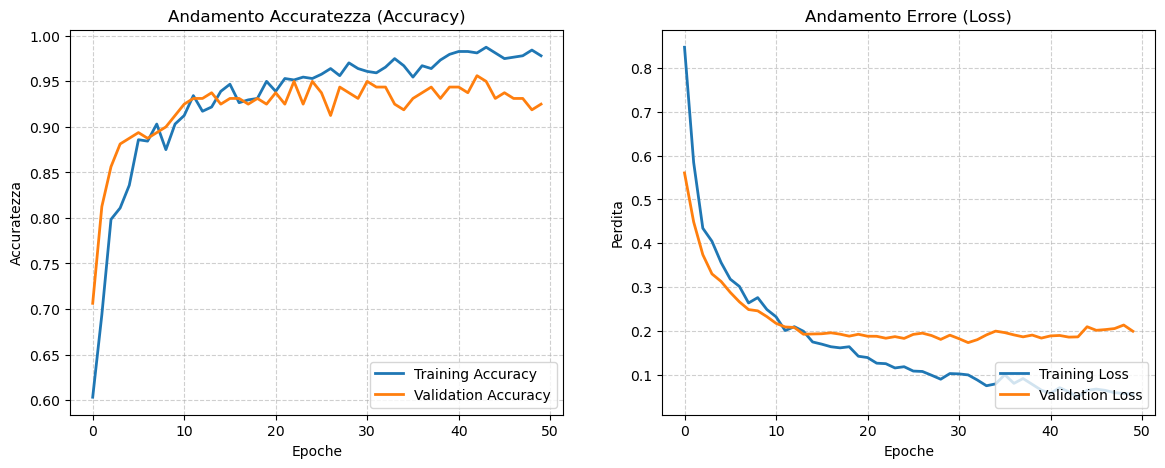

In [37]:
#7.VISUALIZZAZIONE DELLE CURVE DI APPRENDIMENTO
#Creiamo una figura con due grafici (uno per la loss e uno per l'accuratezza)
plt.figure(figsize=(14,5))

#GRAFICO ACCURACY
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy',color='#1f77b4',linewidth=2)
plt.plot(history.history['val_accuracy'],label='Validation Accuracy',color='#ff7f0e',linewidth=2)
plt.title('Andamento Accuratezza (Accuracy)')
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')
plt.legend(loc='lower right')
plt.grid(True,linestyle='--',alpha=0.6)

#GRAFICO ACCURACY
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Training Loss',color='#1f77b4',linewidth=2)
plt.plot(history.history['val_loss'],label='Validation Loss',color='#ff7f0e',linewidth=2)
plt.title('Andamento Errore (Loss)')
plt.xlabel('Epoche')
plt.ylabel('Perdita')
plt.legend(loc='lower right')
plt.grid(True,linestyle='--',alpha=0.6)

plt.show()

Per quanto riguarda l'accuratezza sia il dataset di training che quello di validation salgono in modo abbastanza unito.
Per quanto riguarda l'errore iniziano a dividersi alla 15 esima epocha, sembra ci sia un fili di overfitting, ma non è sufficiente per dire che la nostra rete non stia valutando bene.
Quello che si può fare è cambiare gli iperparametri, provando a aumentare il numero di epoche a 50 (per esempio), per vedere se il grafico migliora o meno (laccuratezza finale del primo testo, con epoche 30 è di 0.935)
Con 50 epoche l'accuratezza finale è migliorata 0.965
si vede che dopo 30 epoche continua a non esserci un miglioramento se non per il training, quindi tutto overfitting, anche su l'accuratezza finale migliora, quindi il modello sta migliorando le sue predizioni